In [1]:
import torch
import torchvision
import matplotlib
import os
import glob

In [2]:
print(torch.cuda.is_available())

True


## Kagglehub를 통한 데이터 다운로드 및 데이터 확인

!pip install kagglehub

import kagglehub



# Download latest version
path = kagglehub.dataset_download("ipythonx/mvtec-ad")

print("Path to dataset files:", path)

In [4]:
from pathlib import Path

print(Path.cwd())

c:\Users\neo\Desktop\seokjin\portfolio\notebooks


In [5]:
data_root = Path("datasets/transistor")

train_good_dir = data_root / "train" / "good"

print(train_good_dir.exists())

print(len(list(train_good_dir.glob("*.png"))))

True
213


## 이미지 한장을 열어서 눈으로 확인하는 단계

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

In [7]:
img_paths = sorted(train_good_dir.glob("*.png"))
img = Image.open(img_paths[0])

In [8]:
print(img.size) # (가로,세로) 픽셀 크기 확인
print(img.mode) # RGB인지 RGBA인지를 확인하는 코드

(1024, 1024)
RGB


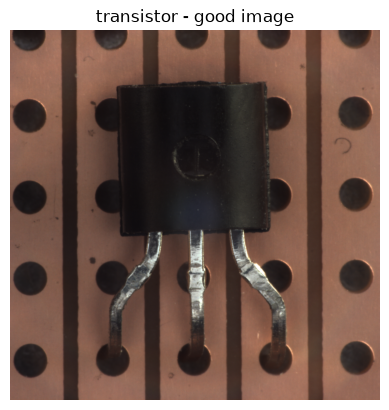

In [9]:
plt.imshow(img)
plt.title("transistor - good image")
plt.axis("off")
plt.show()

## Transform을 정의, 실제로 이미지에 적용하여 Tensor로 변환

In [10]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((256,256)),
    torchvision.transforms.ToTensor() 
    # PIL 이미지의 픽셀값(0~255)을 0~1로 변환 & PIL의 (높이, 너비, 채널) 타입을 torch기반으로 [채널, 높이, 너비]로 변환
])


In [11]:
img_tensor = transform(img)

In [12]:
print(img_tensor.shape) # [채널, 높이, 너비]
print(img_tensor.min())
print(img_tensor.max())

torch.Size([3, 256, 256])
tensor(0.0471)
tensor(1.)


## Tran Dataset 클래스

In [13]:
from torch.utils.data import Dataset

In [14]:
class TransistorTrainDataset(Dataset):
    def __init__(self,root_dir,transform = None):
        self.img_paths = sorted(root_dir.glob("*.png"))
        self.transform = transform
    
    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # 1. idx 첫번째 경로의 이미지를 PIL로 열기
        img = Image.open(self.img_paths[idx]) ## self.img 하지 않아도 됨 -> 현재 함수에서만 사용하고 끝
        # 2. transform 적용
        img_tensor = self.transform(img) ## self.img_tensor 하지 않아도 됨 -> 현재 함수에서만 사용하고 끝
        # 3. tensor 반환
        return img_tensor
    


- self 를 붙이면 instance 변수 (메서드 간에 공유 필요한 변수들을 self를 붙여서 선언)

## Dataset 인스턴스 검증

In [15]:
train_dataset = TransistorTrainDataset(
    root_dir = train_good_dir,
    transform= transform
)

In [16]:
print(len(train_dataset))

print(train_dataset[0].shape)
print(train_dataset[0].min())
print(train_dataset[0].max())

213
torch.Size([3, 256, 256])
tensor(0.0471)
tensor(1.)


- 즉 내가 선언한 TransistorTrainDataset 클래스가 실제 데이터셋에서 잘 적용되는지를 검증하는 단계

## DataLoader 검증

- 병렬처리를 위해 데이터를 묶음 단위로 묶어서 사용

In [17]:
from torch.utils.data import DataLoader

In [18]:
loader = DataLoader(train_dataset,batch_size=16,shuffle=True)

In [19]:
# 한 배치만 꺼내서 확인 -> 16으로 설정했으므로 16장의 배치가 등장
batch = next(iter(loader))

In [20]:
print(batch.shape)

torch.Size([16, 3, 256, 256])


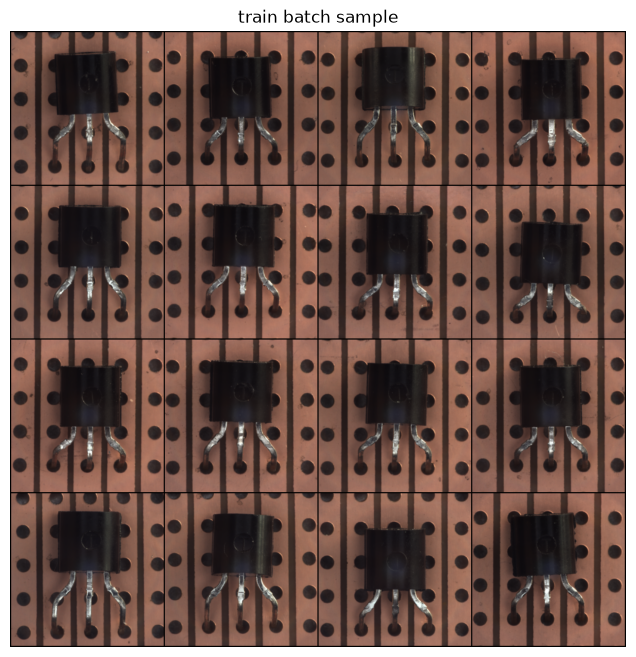

In [21]:
# 배치 이미지 시각화
grid = torchvision.utils.make_grid(batch,nrow=4)
plt.figure(figsize=(12,8))
plt.imshow(grid.permute(1,2,0)) # [채널, 높이, 너비] -> [높이, 너비, 채널]로 변경해야 plt가 인식
plt.axis("off")
plt.title("train batch sample")
plt.show()

## Test dataloader를 만들기 위한 과정

In [25]:
test_dir = data_root / "test"
gt_dir = data_root / "ground_truth"

In [27]:
test_categories = sorted([p.name for p in test_dir.iterdir() if p.is_dir()])
print("test 폴더 목록 : ", test_categories)

test 폴더 목록 :  ['bent_lead', 'cut_lead', 'damaged_case', 'good', 'misplaced']


In [41]:
## 각 폴더별 이미직 개수 확인
for cat in test_categories:
    img = list((test_dir / cat).glob("*.png"))
    print(f"{cat} : {img}")

bent_lead : [WindowsPath('datasets/transistor/test/bent_lead/000.png'), WindowsPath('datasets/transistor/test/bent_lead/001.png'), WindowsPath('datasets/transistor/test/bent_lead/002.png'), WindowsPath('datasets/transistor/test/bent_lead/003.png'), WindowsPath('datasets/transistor/test/bent_lead/004.png'), WindowsPath('datasets/transistor/test/bent_lead/005.png'), WindowsPath('datasets/transistor/test/bent_lead/006.png'), WindowsPath('datasets/transistor/test/bent_lead/007.png'), WindowsPath('datasets/transistor/test/bent_lead/008.png'), WindowsPath('datasets/transistor/test/bent_lead/009.png')]
cut_lead : [WindowsPath('datasets/transistor/test/cut_lead/000.png'), WindowsPath('datasets/transistor/test/cut_lead/001.png'), WindowsPath('datasets/transistor/test/cut_lead/002.png'), WindowsPath('datasets/transistor/test/cut_lead/003.png'), WindowsPath('datasets/transistor/test/cut_lead/004.png'), WindowsPath('datasets/transistor/test/cut_lead/005.png'), WindowsPath('datasets/transistor/test

In [30]:
## ground truth 
gt_categories = sorted([p.name for p in gt_dir.iterdir() if p.is_dir()])
print("ground truth 폴더 목록 : ", gt_categories)

ground truth 폴더 목록 :  ['bent_lead', 'cut_lead', 'damaged_case', 'misplaced']


## Test Dataset 구축
- `__init__`
test dataset은 4개의 폴더를 순회하면서 이미지 경로, 라벨, 마스크를 한번에 수집해야함.

- `__getitem__`
mask는 2가지 경우를 나눠서 처리
    - mask path가 None (good) : torch.zero(1,256,256) > 빈 mask를 생성
    - mask path가 있으면 (defect 이미지) : mask 이미지를 열어서 tensor로 변환

```python
class TransistorTestDataset(Dataset):
    def __init__(self,test_dir,gt_dir transform = None):
        self.labels = []
        # self.mask_paths = []
        
        for folder in test_dir.iterdir():
            for img_path in folder.name:
                self.img_paths = list(sorted(img_path.glob("*.png")))
                if self.img_paths.glob("good") :
                    self.labels.append(0)
                else :
                    self.labels.append(1)
                    self.mask_paths = [p for p in gt_dir.iterdir()]
```
- 처음작성코드 
    1. folder.name으로 받아버리면 문자열이라 이름하나하나의 문자열을 순회
    2. self.mask_paths를 저렇게 선언해버리면 중첩되서 덮어씌여짐.
    3. good인지 아닌지 판단을 하는 위치 잘못설정! > 폴더 이름으로 판단해야함!               

In [26]:
mask_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((256, 256), interpolation=torchvision.transforms.InterpolationMode.NEAREST),
    torchvision.transforms.ToTensor(),
])

In [27]:
class TransistorTestDataset(Dataset):
    def __init__(self,test_dir,gt_dir,transform = None,mask_transform = None):
        self.img_paths = []
        self.labels = []
        self.mask_paths = []
        self.transform = transform
        # 이미지 텐서에는 기존 transform을 사용해야 하므로, mask_transform을 새로 추가해줘야함!
        self.mask_transform = mask_transform
        
        for folder in test_dir.iterdir(): # 라벨링 작업은 폴더단위에서 판단해야함 > 하지만, 라베링 작업은 이미지단위에서 해줘야하므로, label만 결정하고 라벨링작업은 이미지 단위인 밑의 for문에서 실행해야함
            if folder.name == "good":
                label = 0
            else:
                label = 1
            for img_path in folder.glob("*.png"):
                self.img_paths.append(img_path)
                self.labels.append(label)
                
                if folder.name == "good":
                    self.mask_paths.append(None)
                else:
                    mask_path = gt_dir / folder.name / (img_path.stem + "_mask.png")
                    self.mask_paths.append(mask_path)
    def __len__ (self):
        return len(self.img_paths)
    
    def __getitem__(self,idx):
        img = Image.open(self.img_paths[idx])
        img_tensor = self.transform(img)

        label_tensor = torch.tensor(self.labels[idx])

        if self.mask_paths[idx] is None: #if self.mask_paths == None: 이렇게 하면 마스크 패스 리스트 전체와 비교하는 것
            mask_tensor = torch.zeros(1,256,256)
        else:
            mask = Image.open(self.mask_paths[idx]).convert("L")
            mask_tensor = self.mask_transform(mask)
            

        return img_tensor, label_tensor, mask_tensor

In [28]:
test_dataset = TransistorTestDataset(
    test_dir = test_dir,
    gt_dir = gt_dir,
    transform = transform,
    mask_transform = mask_transform
)

In [29]:
print(len(test_dataset))

100


In [101]:
img_tensor,label_tensor,mask_tensor = test_dataset[0]

In [102]:
print(img_tensor.shape)
print(label_tensor)
print(mask_tensor)

torch.Size([3, 256, 256])
tensor(1)
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])


In [103]:
img_tensor,label_tensor,mask_tensor = test_dataset[10]

In [104]:
print(mask_tensor.unique())

tensor([0., 1.])


## AE(Encoder/Decoder)

- Encoder
`Conv2d` 레이어를 쌓아서 이미지를 압축시켜 나감. 
- Decoder
`ConvTranspose2d`를 사용해서 원래 크기로 복원

In [ ]:
class AE(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),       
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=256,out_channels=128,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=128,out_channels=64,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=64,out_channels=32,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=32,out_channels=3,kernel_size=3,stride=2,padding=1),
            torch.nn.Sigmoid() # batchnorm + relu 대신 sigmoid가 와야함 >0~1사이의 값으로 출력해야하기때문

        )
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x    

In [59]:
model = AE()

dummy_input = torch.randn(1,3,256,256)
output = model(dummy_input)

In [60]:
print(dummy_input.shape)
print(output.shape)

torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 241, 241])


- 두 값이 다르게 나옴 . > `ConvTranspose2d`의 출력크기 계산공식 때문 > 결론 `outputpadding `을 더해주면 됨

출력 크기 = (입력크기 - 1) * stride - 2 * padding + kernel_size

In [86]:
class AE(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(512),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=512,out_channels=1024,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(1024),
            torch.nn.ReLU(),       
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=1024,out_channels=512,kernel_size=3,stride=2,padding=1,output_padding=1),
            torch.nn.BatchNorm2d(512),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=512,out_channels=256,kernel_size=3,stride=2,padding=1,output_padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=256,out_channels=128,kernel_size=3,stride=2,padding=1,output_padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=128,out_channels=64,kernel_size=3,stride=2,padding=1,output_padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=64,out_channels=32,kernel_size=3,stride=2,padding=1,output_padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=32,out_channels=3,kernel_size=3,stride=2,padding=1,output_padding=1),
            torch.nn.Sigmoid() # batchnorm + relu 대신 sigmoid가 와야함 >0~1사이의 값으로 출력해야하기때문

        )
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x    

In [87]:
model = AE()

dummy_input = torch.randn(1,3,256,256)
output = model(dummy_input)

In [76]:
print(dummy_input.shape)
print(output.shape)

torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])


## 학습 루프

In [88]:
model = AE()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()
loader = DataLoader(
    train_dataset,
    batch_size = 16,
    shuffle=True,
    num_workers=0,
    pin_memory=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # 모델은 데이터와 다르게 그냥 올려놓으면 됨
num_epochs = 100

In [89]:
for epoch in range(num_epochs):
    for batch in loader:
        # 1. gpu 올리기
        X= batch.to(device)
        # 2. forward pass
        outputs = model(X)
        # 3. loss 계산
        loss = loss_fn(outputs,X)
        # 4. optimizer.zero_grad()
        optimizer.zero_grad()
        # 5. loss.backward()
        loss.backward()
        # 6. optimizer.step()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss : {loss.item():.4f}")

Epoch 1/100, Loss : 0.0401
Epoch 2/100, Loss : 0.0256
Epoch 3/100, Loss : 0.0165
Epoch 4/100, Loss : 0.0110
Epoch 5/100, Loss : 0.0096
Epoch 6/100, Loss : 0.0056
Epoch 7/100, Loss : 0.0048
Epoch 8/100, Loss : 0.0041
Epoch 9/100, Loss : 0.0038
Epoch 10/100, Loss : 0.0036
Epoch 11/100, Loss : 0.0031
Epoch 12/100, Loss : 0.0031
Epoch 13/100, Loss : 0.0029
Epoch 14/100, Loss : 0.0026
Epoch 15/100, Loss : 0.0031
Epoch 16/100, Loss : 0.0025
Epoch 17/100, Loss : 0.0025
Epoch 18/100, Loss : 0.0026
Epoch 19/100, Loss : 0.0023
Epoch 20/100, Loss : 0.0024
Epoch 21/100, Loss : 0.0019
Epoch 22/100, Loss : 0.0021
Epoch 23/100, Loss : 0.0018
Epoch 24/100, Loss : 0.0017
Epoch 25/100, Loss : 0.0018
Epoch 26/100, Loss : 0.0019
Epoch 27/100, Loss : 0.0017
Epoch 28/100, Loss : 0.0016
Epoch 29/100, Loss : 0.0014
Epoch 30/100, Loss : 0.0016
Epoch 31/100, Loss : 0.0015
Epoch 32/100, Loss : 0.0014
Epoch 33/100, Loss : 0.0013
Epoch 34/100, Loss : 0.0017
Epoch 35/100, Loss : 0.0014
Epoch 36/100, Loss : 0.0015
E

- AE는 정답데이터가 없음. 그래서 loss 를 계산할 때는, model을 통과한 output과 X 자기 자신을 비교해서 loss를 계산.
- 지도학습처럼 라벨이 따로 존재하지 않고, `내가 넣은것과 얼마나 비슷하게 복원`하는지로 loss를 판별
- 애초에 train_dataset에서 `__getitem__`의 반환값이 이미지 tensor하나밖에 없음

## 평가모드

- Image AUROC : 해당 이미지가 정상인지 아닌지 확인하고 싶음 > 이미지 한장당의 평가
- Pixel AUROC : 이미지의 어느부분이 불량인지를 확인하고 싶음 > 픽셀 당의 평가

### 실제 test 데이터셋에 적용

- 위에서 진행했던 이미지 한장에 대한 과정을 `모든 이미지에 대해 반복`하여

```python
anomaly_scores = [0.002, 0.15, 0.003, 0.21, ...]   # 각 이미지의 anomaly score
true_labels    = [0,     1,    0,     1,    ...]   # 각 이미지의 실제 라벨 (0=good, 1=defect)
```
이렇게 출력되도록.
`sklearn.metrics.roc_auc_score(true_labels,anomaly_scores)`에 넣으면 IMAGE AUROC값이 바로 계산.


- Pixel AUROC 
모든 픽셀의 오차값과 ground truth mask 값도 모아야함.

```python
pixel_scores = [픽셀1 오차, 픽셀2 오차, ...]   # 모든 이미지의 모든 픽셀을 펼친 것
pixel_labels = [픽셀1 mask값, 픽셀2 mask값, ...]  # 대응하는 ground truth
```

In [90]:
test_dataloader = DataLoader(test_dataset,batch_size = 16, shuffle=False,num_workers=0)

model.eval()

anomaly_scores = []
all_labels = []
pixel_scores = []
pixel_labels = []


with torch.no_grad():
    for img_tensor, label, mask_tensor in test_dataloader:
        img_tensor = img_tensor.to(device)
        output = model(img_tensor)

        error = (img_tensor - output)**2

        anomaly_map = error.mean(dim=1) # map을 만들때는 일단 RGB로 평균을 내는 것은 맞음. 그럼 현재 차원 [16,256,256]

        # anomaly_scores.append(anomaly_map.mean().item()) 
        ##이렇게 작성하면 batch의 값들을 하나의 평균값으로 만들어버림. > 하지만 우리가 원하는 건 16장의 각각의 score임
        
        ## 우리는 현재 [16,256,256]의 값이 존재하는 상황 ->[16]만 남겨둬야함.
        anomaly_score = anomaly_map.mean(dim=(1,2))
        anomaly_scores.extend(anomaly_score.cpu().numpy())

        all_labels.extend(label.numpy())

        pixel_scores.extend(anomaly_map.cpu().numpy().flatten())
        pixel_labels.extend(mask_tensor.numpy().flatten())

## 결과값 계산

In [91]:
from sklearn.metrics import roc_auc_score

In [92]:
image_auroc = roc_auc_score(all_labels,anomaly_scores)
pixel_auroc = roc_auc_score(pixel_labels,pixel_scores)

print(f"Image score : {image_auroc:.4f}")
print(f"Pixel score : {pixel_auroc:.4f}")

Image score : 0.8142
Pixel score : 0.7520


- 결과값이 너무 낮게 나옴 

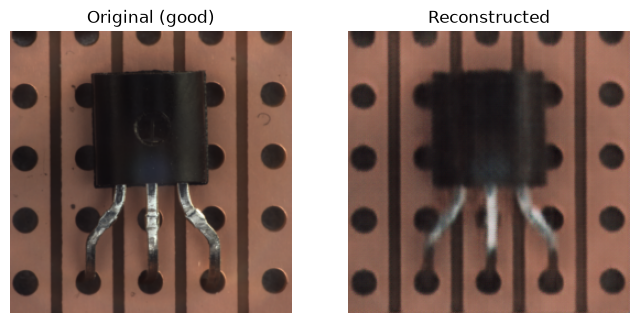

In [82]:
model.eval()

sample = train_dataset[0].unsqueeze(0).to(device)

with torch.no_grad():
    recon = model(sample)

fig,axes = plt.subplots(1,2,figsize=(8,4))
axes[0].imshow(sample[0].cpu().permute(1,2,0))
axes[0].set_title("Original (good)")
axes[0].axis("off")

axes[1].imshow(recon[0].cpu().permute(1,2,0))
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.show()

- 성능이 낮게 나오는 이유 및 검증하기. 

In [93]:
import numpy as np
anomaly_score_arr = np.array(anomaly_scores)
all_labels_arr = np.array(all_labels)

good_scores = anomaly_score_arr[all_labels_arr==0]
defect_scores = anomaly_score_arr[all_labels_arr==1]

print(f"Good 평균 scores : {good_scores.mean():.4f}")
print(f"Defect 평균 scores : {defect_scores.mean():.4f}")

Good 평균 scores : 0.0010
Defect 평균 scores : 0.0019


In [83]:
import numpy as np

anomaly_scores_arr = np.array(anomaly_scores)
all_labels_arr = np.array(all_labels)

good_scores = anomaly_scores_arr[all_labels_arr == 0]
defect_scores = anomaly_scores_arr[all_labels_arr == 1]

print(f"Good 평균 score: {good_scores.mean():.4f}")
print(f"Defect 평균 score: {defect_scores.mean():.4f}")

Good 평균 score: 0.0013
Defect 평균 score: 0.0022


- 현재 mean으로 평가했을때 결과가 좋지 않아서 max로 평가기준을 변경하고 확인.

In [94]:
anomaly_score_max = []

with torch.no_grad():
    for img_tensor, label, mask_tensor in test_dataloader:
        img_tensor = img_tensor.to(device)
        output = model(img_tensor)

        error = (img_tensor - output)**2

        anomaly_map = error.mean(dim=1) # map을 만들때는 일단 RGB로 평균을 내는 것은 맞음. 그럼 현재 차원 [16,256,256]

        # anomaly_scores.append(anomaly_map.mean().item()) 
        ##이렇게 작성하면 batch의 값들을 하나의 평균값으로 만들어버림. > 하지만 우리가 원하는 건 16장의 각각의 score임
        
        ## 우리는 현재 [16,256,256]의 값이 존재하는 상황 ->[16]만 남겨둬야함.
        anomaly_score = anomaly_map.amax(dim=(1,2))
        anomaly_score_max.extend(anomaly_score.cpu().numpy())

image_auroc_max = roc_auc_score(all_labels,anomaly_score_max)
print(f"Image AUROC (max) : {image_auroc_max:.4f}")

Image AUROC (max) : 0.6629


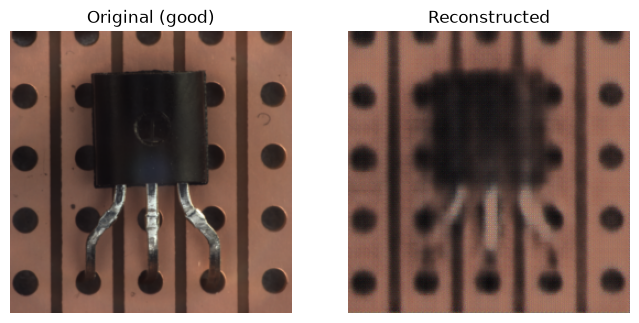

In [47]:
model.eval()

sample = train_dataset[0].unsqueeze(0).to(device)

with torch.no_grad():
    recon = model(sample)

fig,axes = plt.subplots(1,2,figsize=(8,4))
axes[0].imshow(sample[0].cpu().permute(1,2,0))
axes[0].set_title("Original (good)")
axes[0].axis("off")

axes[1].imshow(recon[0].cpu().permute(1,2,0))
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.show()

## 결과저장

### metrics 저장

In [120]:
print(os.getcwd())

c:\Users\neo\Desktop\seokjin\portfolio\notebooks


In [121]:
import json

metrics = {
    "model" : "AutoEncoder",
    "image_auroc" : image_auroc,
    "pixel_auroc" : pixel_auroc,
    "image_auroc_max_score" : image_auroc_max
}

with open("../results/metrics/autoencoder_metrics.json","w") as f:
    json.dump(metrics,f,indent = 4)

### 시각화 저장

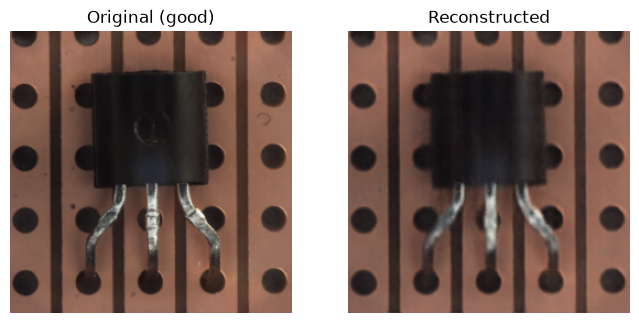

In [95]:
model.eval()

sample = train_dataset[0].unsqueeze(0).to(device)

with torch.no_grad():
    recon = model(sample)

fig,axes = plt.subplots(1,2,figsize=(8,4))
axes[0].imshow(sample[0].cpu().permute(1,2,0))
axes[0].set_title("Original (good)")
axes[0].axis("off")

axes[1].imshow(recon[0].cpu().permute(1,2,0))
axes[1].set_title("Reconstructed")
axes[1].axis("off")


plt.show()

##### Defect이미지의 anomaly heatmap 저장 
- 원본이미지, 복원 이미지, 모델이 예측한 anomaly map, ground truth mask

```python
axes[].imshow(,permute(1,2,0))
```

permute : 차원의 순서를 바꿔줌. 
torch는 (채널, 높이, 너비) 순서로 받지만, plt는 (높이,너비, 채널) 순서로 받길 원함.
따라서 permute을 사용해서 plt가 원하는 순서의 인덱스 번호대로 바꿔줌.

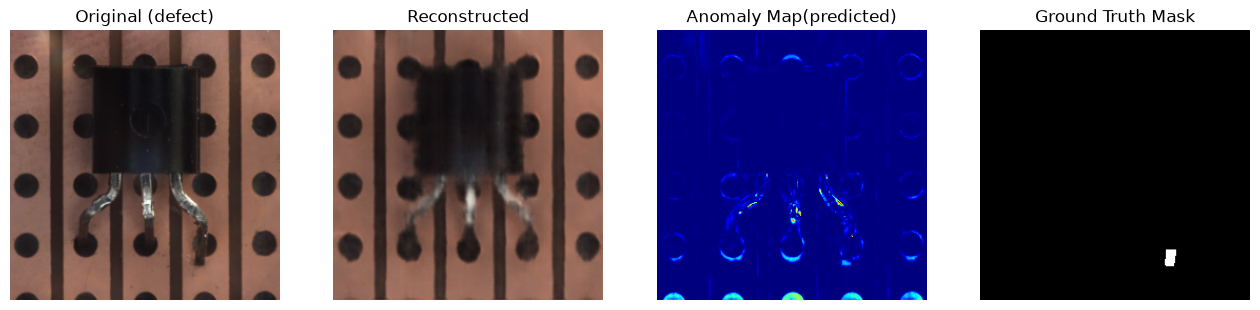

In [96]:
defect_idx = None
for i in range(len(test_dataset)):
    _,label,_ = test_dataset[i]
    if label == 1:
        defect_idx = 1
        break

img_tensor, label, mask_tensor = test_dataset[defect_idx]
img_input = img_tensor.unsqueeze(0).to(device)


with torch.no_grad():
    output = model(img_input)

error = (img_input- output)**2

anomaly_map = error.mean(dim=1)[0].cpu()

fig,axes = plt.subplots(1,4,figsize=(16,4))

axes[0].imshow(img_tensor.permute(1,2,0))
axes[0].set_title("Original (defect)")
axes[0].axis("off")

axes[1].imshow(output[0].cpu().permute(1,2,0))
# 배치 차원을 가지고 있어서 배치차원을 없애기 위해 인덱싱을 통해 배치 차원을 없애줌
axes[1].set_title("Reconstructed")
axes[1].axis("off")

axes[2].imshow(anomaly_map, cmap="jet")
axes[2].set_title("Anomaly Map(predicted)")
axes[2].axis("off")

axes[3].imshow(mask_tensor[0],cmap="gray") 
## mask_tensor는 원래 3차원 [1,256,256]. 즉, 채널의 차원이 남아 있어서 이걸 없애주려고. > plt가 이미지를 그릴때 2차원을 원함
## mask_tensor는 처음 선언할 때부터 2차원의 흑백이미지였기때문에.
axes[3].set_title("Ground Truth Mask")
axes[3].axis("off")


plt.show()


- AutoEncoder의 성능 한계를 평가할 수 있음.

- 